In [1]:
import numpy as np

perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

In [3]:
from sklearn.model_selection import train_test_split

train_x,test_x,train_y,test_y = train_test_split(perch_length,perch_weight,random_state = 42)
train_x = train_x.reshape(-1,1)
test_x = test_x.reshape(-1,1)
#sklearn에서 데이터는 2차원 배열임 따라서 2차원 배열로 변경

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knr = KNeighborsRegressor(n_neighbors=3)

knr.fit(train_x,train_y)
knr.predict([[50]])# knn의 문제점 발생 만약 [50]이 아닌 [10000]이 나와도 주변 클래스의 평균이라 같은 값을 예측함

array([1033.33333333])

In [5]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(train_x,train_y)
lr.predict([[50]])

array([1241.83860323])

In [ ]:
print(lr.coef_,lr.intercept_) #가중치와 바이어스

[39.01714496] -709.0186449535474


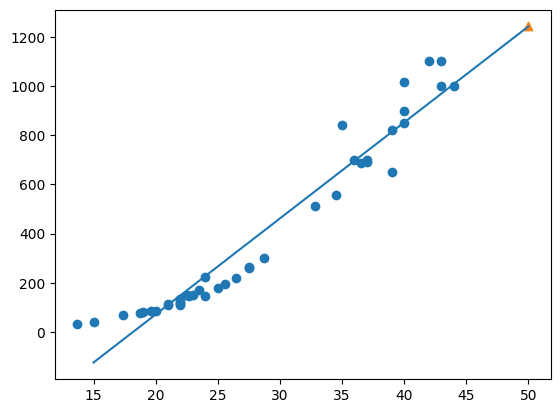

In [7]:
import matplotlib.pyplot as plt

plt.scatter(train_x,train_y)
plt.plot([15,50],[15*lr.coef_+lr.intercept_,50*lr.coef_+lr.intercept_])

plt.scatter(50,1241.8,marker="^")
plt.show()

In [ ]:
train_poly = np.column_stack((train_x**2,train_x))
test_poly = np.column_stack((test_x**2,test_x))

lr.fit(train_poly,train_y)
print(lr.predict([[50**2,50]]))

[1573.98423528]


In [ ]:
lr.coef_,lr.intercept_

#1.104~ : x^2의 계수, -21.~ : x의 계수, 116.05~: y절편

(array([  1.01433211, -21.55792498]), 116.0502107827827)

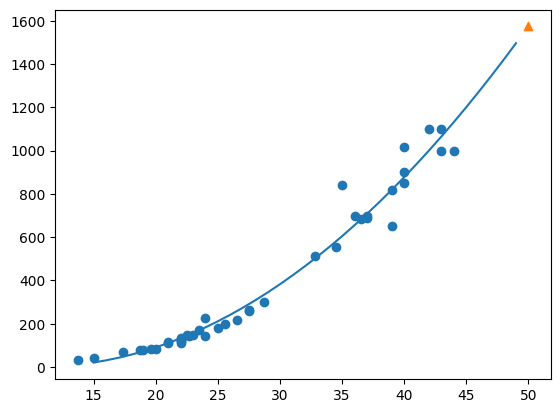

In [11]:
plt.scatter(train_x,train_y)
point = np.arange(15,50)

plt.plot(point,1.015*point**2-21.558*point+116.050)
plt.scatter(50,1574,marker="^")
plt.show()